# Modélisation - Telco Customer Churn

Objectif : entraîner plusieurs modèles de classification, les comparer, optimiser le meilleur, puis le sauvegarder.

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

## 2. Chargement et préparation

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Train :", X_train.shape, " Test :", X_test.shape)

Train : (5634, 29)  Test : (1409, 29)


## 3. Modèles

On compare 4 modèles classiques pour un problème de classification binaire, avec des hypothèses différentes (linéaire, ensembliste, marge maximale).

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    print(f"{name} entraîné.")

Logistic Regression entraîné.


Random Forest entraîné.


Gradient Boosting entraîné.


SVM entraîné.


In [4]:
results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
results_df.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Gradient Boosting,0.806,0.662,0.545,0.598,0.842
Logistic Regression,0.801,0.647,0.553,0.597,0.841
SVM,0.796,0.657,0.481,0.556,0.798
Random Forest,0.780,0.609,0.479,0.536,0.821


**Pourquoi le F1-score pour classer les modèles, et pas seulement l'Accuracy ?**
Rappel de l'EDA : les classes sont déséquilibrées (~26% churn / ~74% non-churn). Un modèle qui prédit toujours "non-churn" aurait déjà ~74% d'Accuracy sans rien apprendre. Le F1-score (moyenne harmonique de Precision et Recall) est plus fiable ici.

### 3.1 Optimisation du meilleur modèle (GridSearchCV)

In [5]:
best_model_name = results_df.index[0]
print("Meilleur modèle avant optimisation :", best_model_name)

# Grilles d'hyperparamètres adaptées à chaque type de modèle
param_grids = {
    "Logistic Regression": {"C": [0.01, 0.1, 1, 10]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [5, 10, None], "min_samples_split": [2, 5]},
    "Gradient Boosting": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
    "SVM": {"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]}
}

# On optimise le modèle qui a réellement gagné (pas un modèle fixé d'avance)
grid = GridSearchCV(
    models[best_model_name],
    param_grids[best_model_name],
    cv=5, scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur F1 (validation croisée) :", round(grid.best_score_, 3))

best_model = grid.best_estimator_

Meilleur modèle avant optimisation : Gradient Boosting


Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Meilleur F1 (validation croisée) : 0.575


## 4. Évaluation

In [6]:
y_pred_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=["Reste", "Churn"]))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_final), 3))

              precision    recall  f1-score   support

       Reste       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC : 0.842


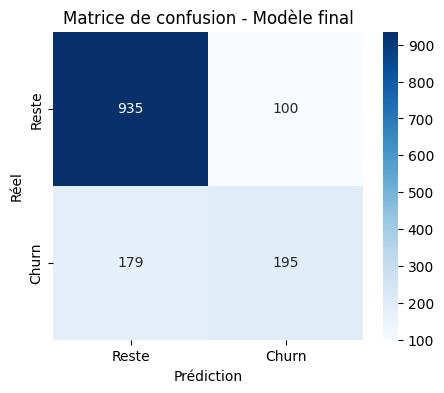

In [7]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Reste", "Churn"], yticklabels=["Reste", "Churn"])
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Modèle final")
plt.savefig("../confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

### 4.1 Comparaison visuelle des modèles

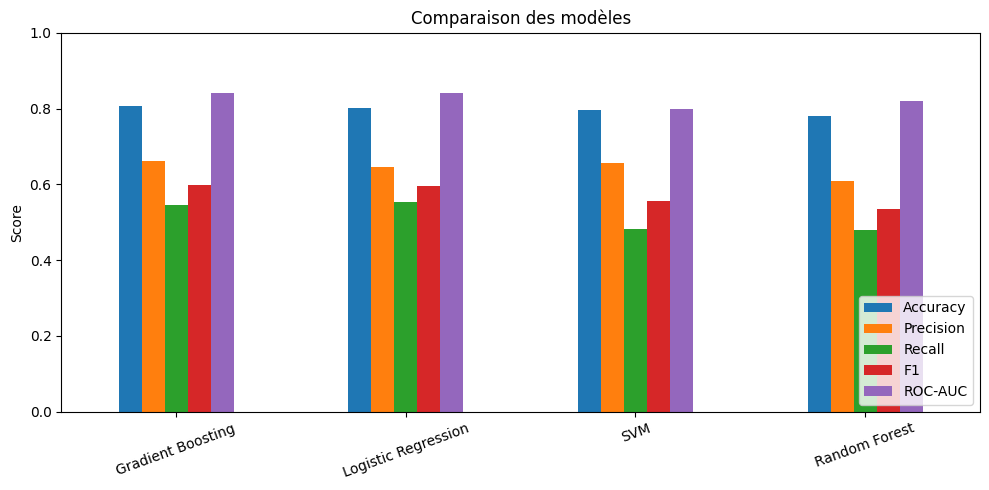

In [8]:
results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1)
)
plt.title("Comparaison des modèles")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../models_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

## 5. Sauvegarde du meilleur modèle

In [9]:
joblib.dump(best_model, "../models/best_model.pkl")
print("Modèle sauvegardé : models/best_model.pkl")

Modèle sauvegardé : models/best_model.pkl


## Conclusion de la modélisation
- 4 modèles comparés : Logistic Regression, Random Forest, Gradient Boosting, SVM
- Métrique de sélection : F1-score (justifié par le déséquilibre des classes)
- Meilleur modèle optimisé par GridSearchCV (validation croisée 5-fold)
- Modèle final sauvegardé dans `models/best_model.pkl`, prêt à être réutilisé (ex : application Streamlit bonus)

À préparer pour l'oral : être capable d'expliquer pourquoi ce modèle gagne, ce que mesurent Precision/Recall/F1/ROC-AUC, et ce que signifie la matrice de confusion (faux positifs vs faux négatifs — ici, un faux négatif = un client qu'on pensait fidèle mais qui part, ce qui coûte cher à l'entreprise).